# Computer Vision

In [52]:
!pip install torchmetrics

In [53]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from pathlib import Path
import requests

if not Path('helper_functions.py').is_file():
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open('helper_functions.py', 'wb') as f:
        f.write(request.content)

from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm

## Getting a dataset

In [54]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True
)

test_data = datasets.FashionMNIST(
    root='data',
    train=None,
    transform=ToTensor(),
    target_transform=None,
    download=True
)


## Visualizing Dataset

Visualizing the data
Shape of train_data:  torch.Size([60000, 28, 28])
Classes of train_data:  ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Classes of train data in index form:  {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Shape of train data label:  torch.Size([60000])

Example of a data
Label(Idx):  tensor(9)
Label(Class):  Ankle boot


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

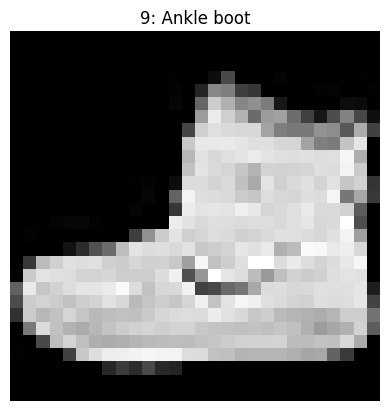

In [55]:
print('Visualizing the data')
print('Shape of train_data: ', train_data.data.shape)
print('Classes of train_data: ', train_data.classes)
print('Classes of train data in index form: ', train_data.class_to_idx)
print('Shape of train data label: ', train_data.targets.shape)


print('\nExample of a data')
print('Label(Idx): ', train_data.targets[0])
print('Label(Class): ', train_data.classes[train_data.targets[0]])

plt.imshow(train_data.data[0], cmap='gray')
plt.title(f'{train_data.targets[0]}: {train_data.classes[train_data.targets[0]]}')
plt.axis('off')



## Data Loader

In [56]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=32,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [57]:
## Visualize dataloader
images, labels = next(iter(train_dataloader))
print('Number of batches in total (train data): ', len(train_dataloader))
print('Size of an image batch: ', images.shape)
print('Size of a label batch: ', labels.shape)

Number of batches in total (train data):  1875
Size of an image batch:  torch.Size([32, 1, 28, 28])
Size of a label batch:  torch.Size([32])


## Build a model

In [58]:
class VisionModel(nn.Module):
    def __init__(self, 
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            ) # 14 x 14
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            ) # 7 x 7
        ) 

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=7*7*hidden_units,
                out_features=output_shape
            )
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out1 = self.conv_block_1(x)
        out2 = self.conv_block_2(out1)
        out3 = self.classifier(out2)
        return out3

## Training

In [59]:
# Hyperparameter
MANUAL_SEED = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
LEARNING_RATE = 1E-1
EPOCHS = 3

# Seed
torch.manual_seed(MANUAL_SEED)
torch.cuda.manual_seed(MANUAL_SEED)

# Model
model_0 = VisionModel(input_shape=1, 
                      hidden_units=10, 
                      output_shape=len(train_data.classes)
                      ).to(device)

# Metrics
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr = LEARNING_RATE)
acc_fn = MulticlassAccuracy(num_classes=len(train_data.classes), average='macro').to(device)

# Training / Testing Loop
for epoch in range(EPOCHS):
    
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []

    # Train
    for batch_idx, (X, y) in tqdm(enumerate(train_dataloader)):
        model_0.train()
        X,y = X.to(device), y.to(device)
        y_logits = model_0(X)

        train_loss = loss_fn(y_logits, torch.nn.functional.one_hot(y, num_classes=len(train_data.classes)).to(torch.float32))
        train_acc = acc_fn(torch.argmax(y_logits, dim=1).squeeze(), y)

        train_losses.append(train_loss.item())
        train_accs.append(train_acc.item())
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

    # Eval
    for batch_idx, (X,y) in tqdm(enumerate(test_dataloader)):
        
        model_0.eval()
        with torch.inference_mode():
            X,y = X.to(device), y.to(device)
            y_logits = model_0(X)

            test_loss = loss_fn(y_logits, torch.nn.functional.one_hot(y, num_classes=len(train_data.classes)).to(torch.float32))
            test_acc = acc_fn(torch.argmax(y_logits, dim=1).squeeze(), y)

            test_losses.append(test_loss.item())
            test_accs.append(test_acc.item())

    # Print results
    print('Epoch: ', epoch)
    print(f'Avg train loss: {sum(train_losses)/len(train_losses):.2f} | Avg train accuracy: {sum(train_accs)/len(train_accs):.2f}')
    print(f'Avg test loss: {sum(test_losses)/len(test_losses):.2f} | Avg test accuracy: {sum(test_accs)/len(test_accs):.2f}')



0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  0
Avg train loss: 0.58 | Avg train accuracy: 0.78
Avg test loss: 0.39 | Avg test accuracy: 0.84


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  1
Avg train loss: 0.36 | Avg train accuracy: 0.86
Avg test loss: 0.38 | Avg test accuracy: 0.85


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  2
Avg train loss: 0.32 | Avg train accuracy: 0.88
Avg test loss: 0.32 | Avg test accuracy: 0.87
